<a href="https://colab.research.google.com/github/vadimgb1/fashion/blob/main/HODL_SP24_Lec_03B_Learning_an_Image_Classification_Model_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Обучение модели классификации изображений с нуля

* Based on [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python-second-edition?gclid=CjwKCAjw9aiIBhA1EiwAJ_GTSlKgxc4qopKHPsFWryOoTz7fvhvhzYSjEsgQ-bG1R51QSGppISywpBoClcIQAvD_BwE) by Francois Chollett


### Набор данных Fashion MNIST



 [fashion_mnist](https://github.com/zalandoresearch/fashion-mnist) набор данных состоит из 70 000 изображений предметов одежды, отнесенных к 10 категориям.

![Fashion MNIST](fashion-mnist-sprite.png)



<br>

К счастью, этот набор данных доступен в удобном формате через Keras, поэтому мы загрузим его и посмотрим.

Но сначала давайте разберемся с некоторыми техническими моментами.



---



---



---


Сначала мы импортируем следующие пакеты и установим начальное значение для генератора случайных чисел.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# инициализируйте начальные значения различных генераторов случайных чисел таким образом, чтобы
# результаты были одинаковыми при каждом запуске notebook.
keras.utils.set_random_seed(42)

I0000 00:00:1774624902.905502   57417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774624904.000404   57417 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774624908.049286   57417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Разобравшись с техническими тонкостями, давайте загрузим набор данных и посмотрим, что получится.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


В обучающем наборе содержится 60 000 изображений, каждое из которых представляет собой матрицу размером 28x28.

In [4]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


Оставшиеся 10 000 изображений входят в тестовый набор.

<br>

Хорошо, давайте посмотрим на первые 10 строк зависимой переменной. $y$.





In [5]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

**Что означают эти цифры?**

Согласно [Fashion MNIST Github site](https://github.com/zalandoresearch/fashion-mnist#labels), Вот чему соответствует каждая цифра от 0 до 9:

| Label  | Description  |
|---|---|
|  0 | футболка/топ  |
|  1 |  Брюки |
|  2 |   Пуловер |
|  3 |  Платье |
|  4 |  Пальто |
|  5 |  Сандалии |
|  6 |   Рубашка |
|  7 |  Кроссовки |
|  8 |   Сумка |
|  9 |  Ботильоны |

Давайте создадим небольшой список на Python, чтобы нам было проще преобразовывать числа в описания.

In [6]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]



Теперь, имея число, описание можно легко найти в справочнике. Давайте посмотрим, о чём идёт речь в самом первом обучающем примере.

In [7]:
labels[y_train[0]]

'Ankle boot'

На первом изображении — "ботильоны"!

Давайте посмотрим на **исходные данные** изображения.

In [8]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

Давайте посмотрим на первые 25 изображений.



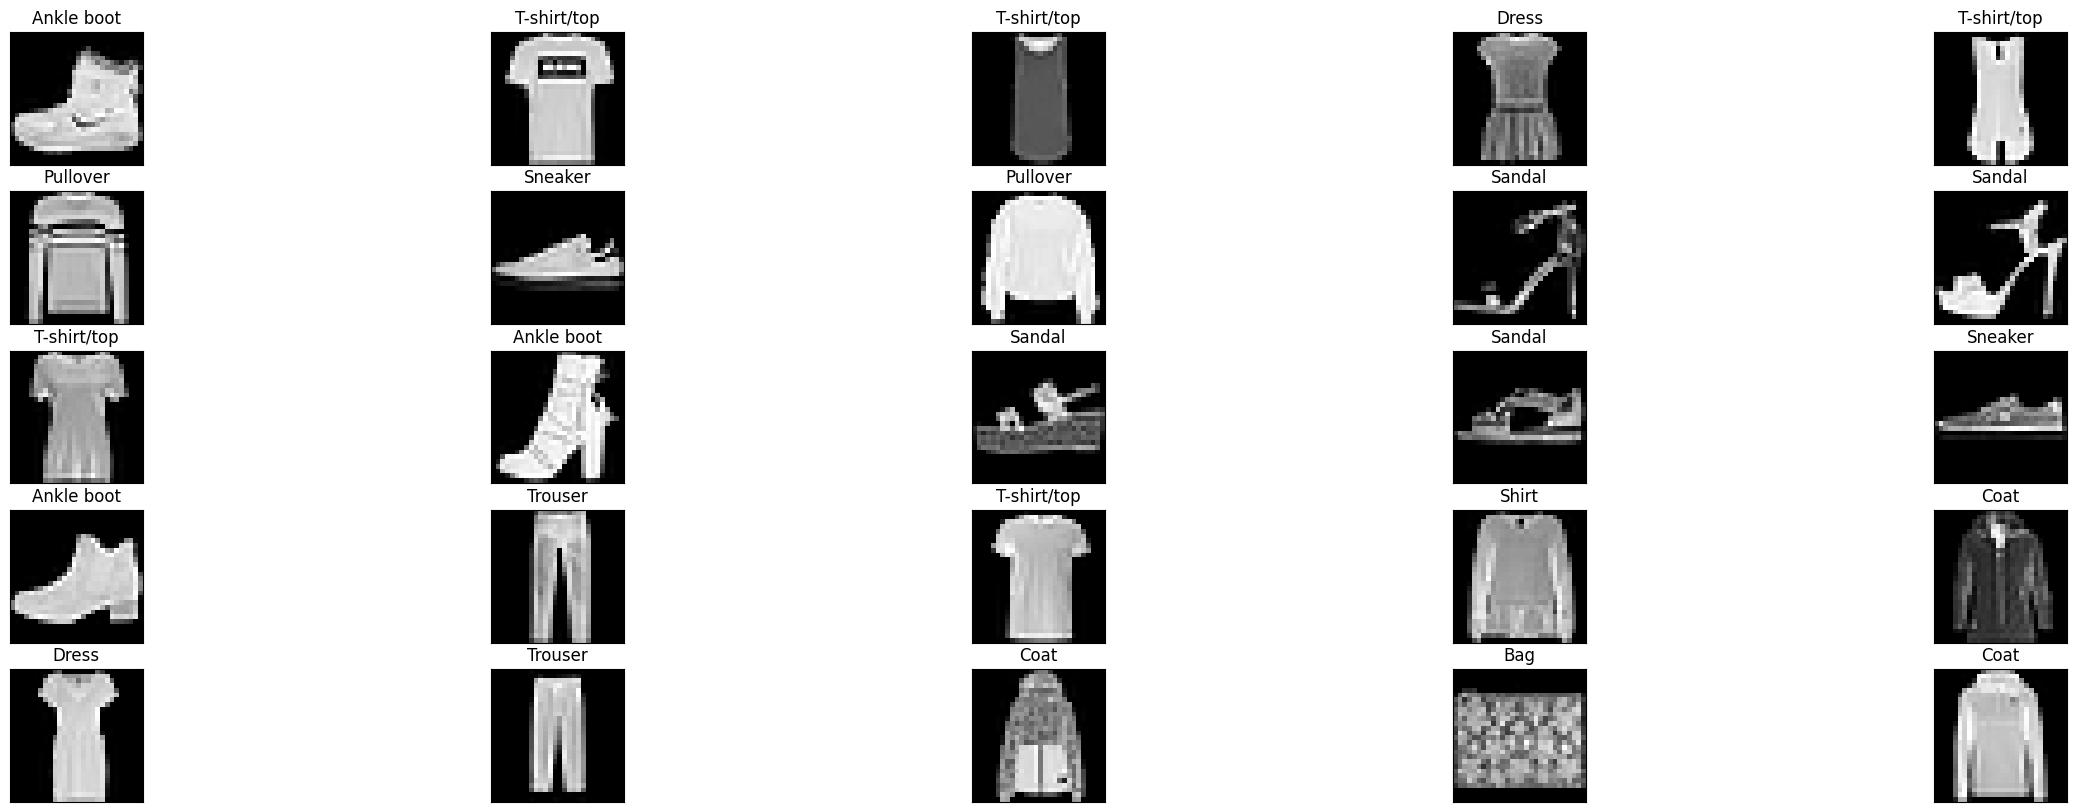

In [9]:
fig, ax = plt.subplots(5, 5, figsize=(30, 10))
for i in range(25):
  axc = ax[i//5, i%5]
  axc.imshow(x_train[i], cmap="gray")
  axc.set_title(f"{labels[y_train[i]]}")
  axc.set_xticks([])
  axc.set_yticks([])

## NN Модель

### Подготовка данных

**Tip**: Нейронные сети лучше всего обучаются, когда каждая независимая переменная находится в небольшом диапазоне. Поэтому стандартизируйте их по одному из следующих критериев:
- вычитание среднего значения и деление на стандартное отклонение или
- если значения находятся в гарантированном диапазоне, просто разделите на максимальное значение.

Входные значения здесь варьируются от 0 до 255. Давайте нормализуем их до диапазона 0-1, разделив все на 255.

In [10]:
x_train = x_train/ 255.0
x_test = x_test/ 255.0

### Определение модели в Keras

Краткий обзор нейронной сети, которую мы разработали на занятии:

* Входными данными будут матрицы чисел размером 28 x 28. Их необходимо *преобразовать* в очень длинный вектор, а затем подать на следующий слой.

* Мы будем использовать только один скрытый слой.

* Поскольку это *задача многоклассовой классификации* (например, нам нужно предсказать одну из 10 категорий одежды), выходной слой должен выдавать вектор вероятностей из 10 элементов, сумма которых равна 1,0 => мы будем использовать слой *softmax*.

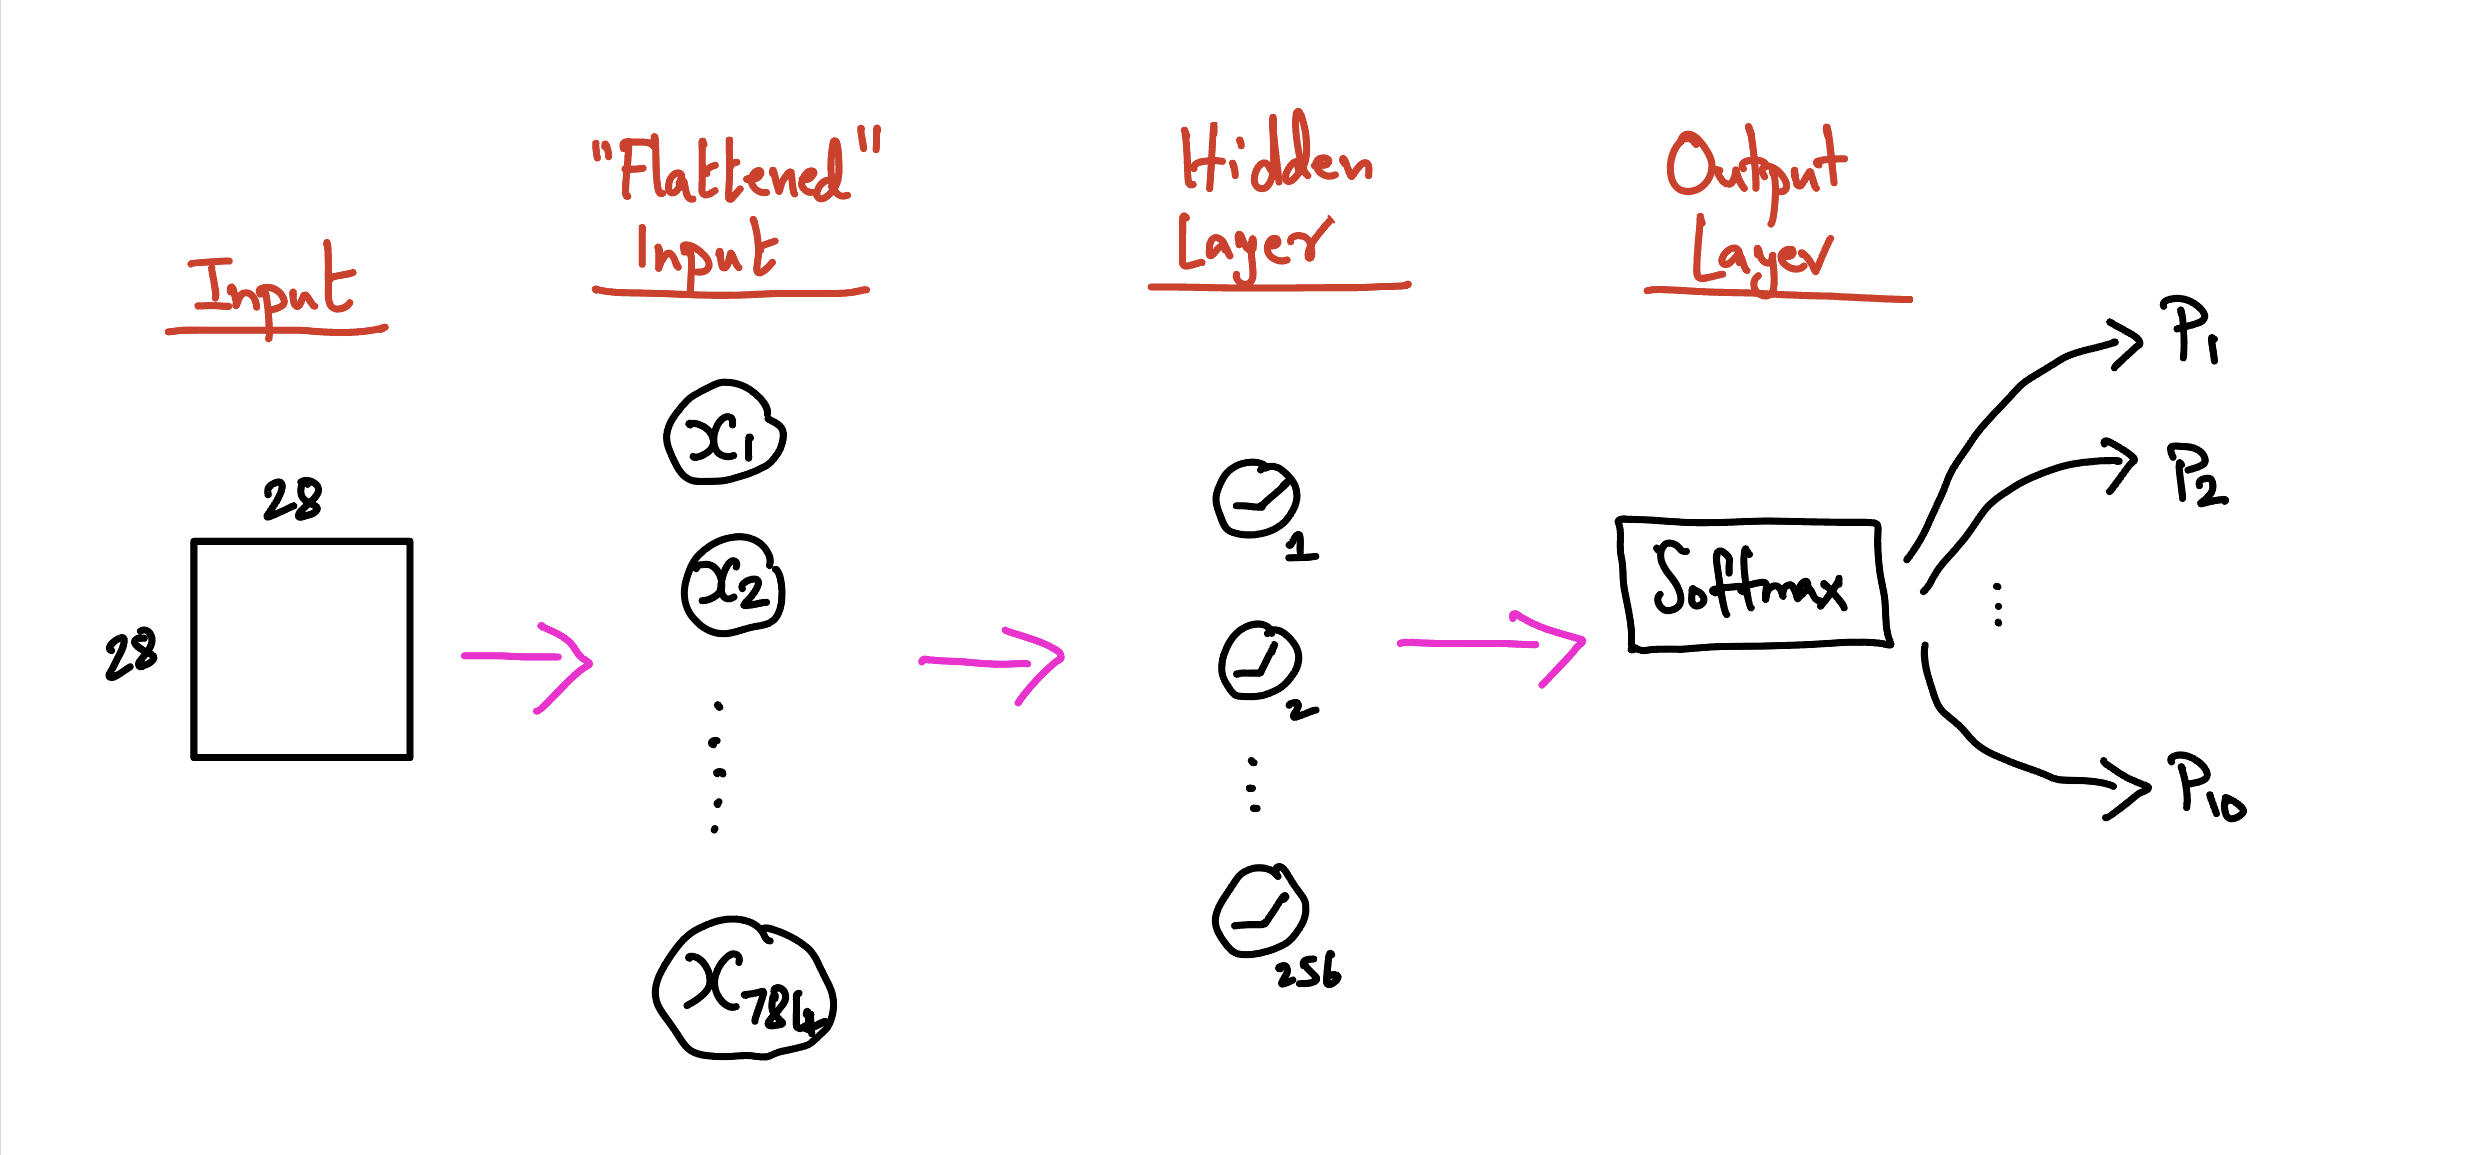

In [11]:
28 * 28


784

Давайте "переведём" это на язык Keras.

In [12]:
# define the input layer
input = keras.Input(shape=(28,28))

# convert the 28 x 28 matrix of numbers into a loooooooong vector
h = keras.layers.Flatten()(input)

# feed the long vector to the hidden layer
h = keras.layers.Dense(256, activation="relu", name="Hidden")(h)

# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(10, activation="softmax", name="Output")(h)

# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

E0000 00:00:1774624912.939821   57417 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 `model.summary()` Эта команда — хороший способ быстро получить общее представление о том, что вы определили.

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Давайте вручную рассчитаем количество параметров, которые необходимо проверить.

In [14]:
(784 * 256 + 256) + (256 * 10 + 10)

203530

Мы также можем "визуализировать" сеть графически, используя функцию `plot_model` в Keras.

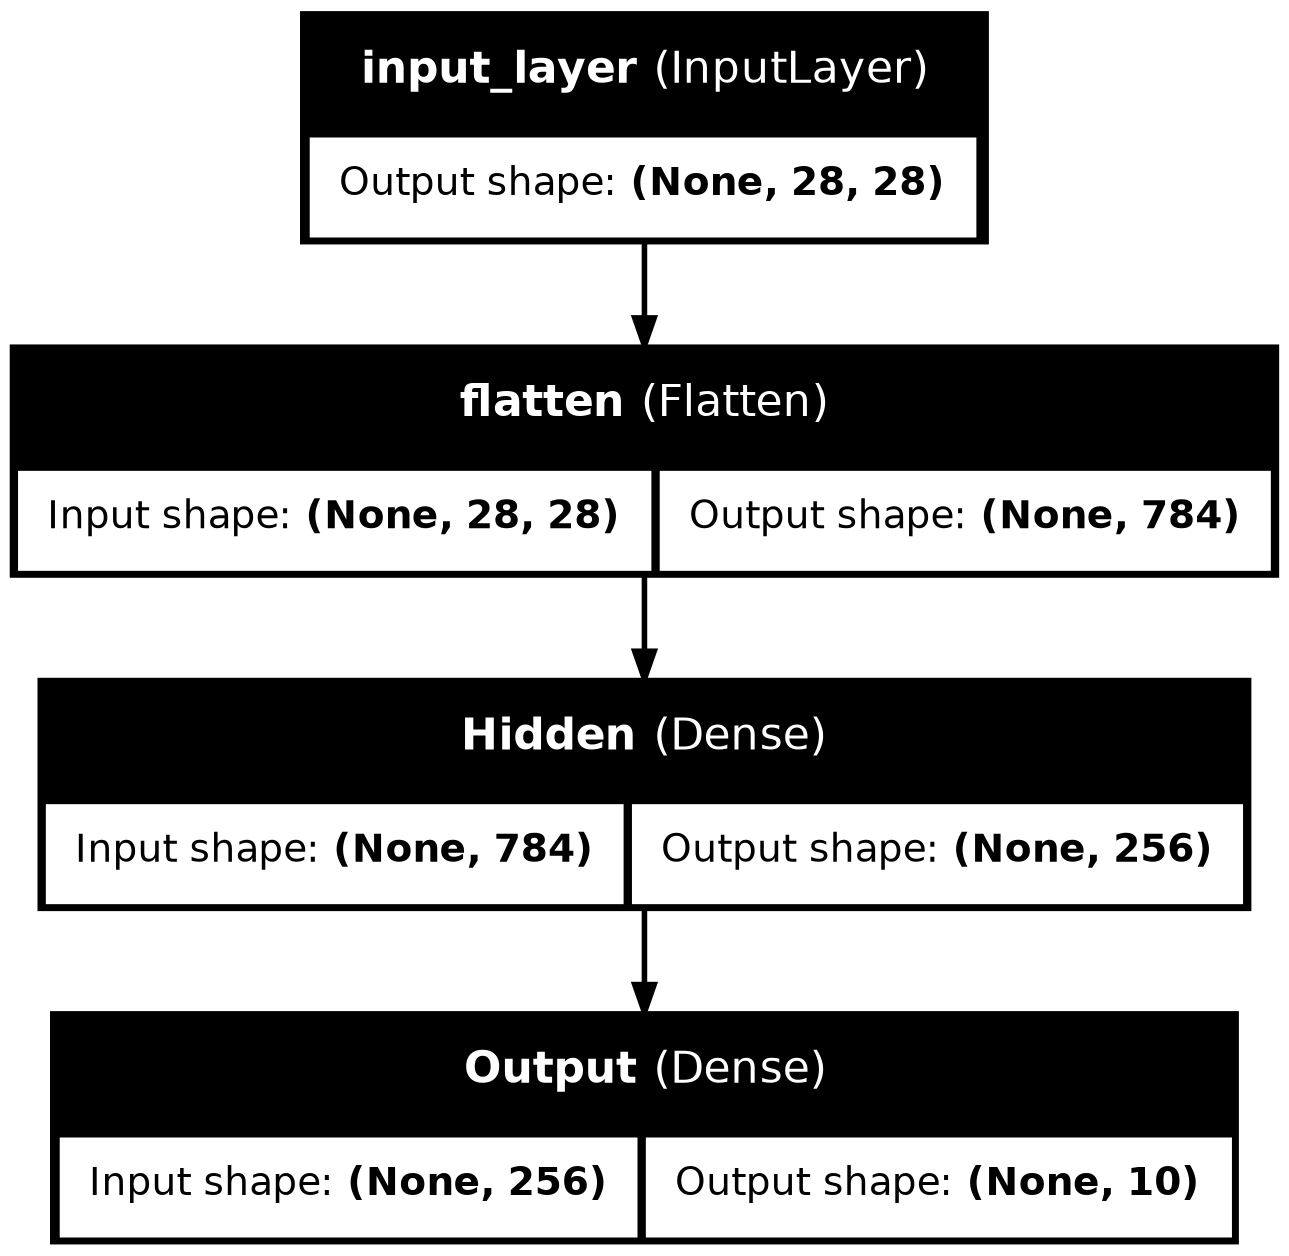

In [15]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

### Задать параметры оптимизации

Теперь, когда модель определена, нам нужно сообщить Keras три вещи:

* Какую **функцию потерь** использовать
* Какой **оптимизатор** использовать — мы снова воспользуемся **Adam**, который является отличным вариантом, не требующим дополнительных настроек
* Какие **метрики** вы хотите, чтобы Keras отображал — в задачах классификации, подобных этой, обычно требуется точность.


Поскольку наша выходная переменная является категориальной и имеет 10 уровней, мы выберем функцию потерь `sparse_categorical_crossentropy`. Вспомните этот слайд из лекции:


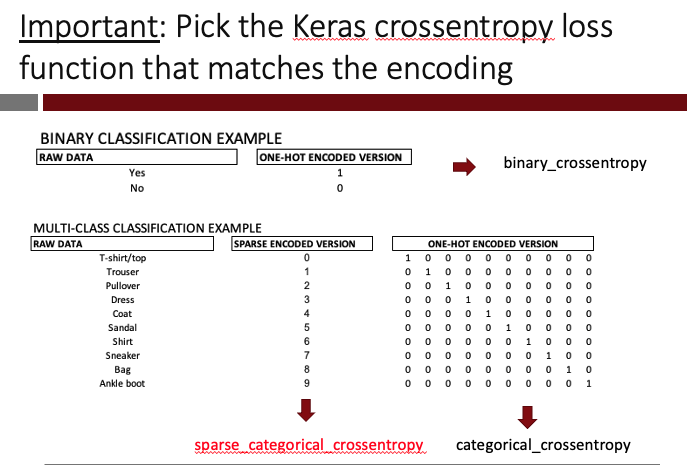

In [16]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

### Обучение модели!

* Размер *пакета данных*: обычно используются значения 32 или 64.
* Количество *эпох*, т.е. сколько проходов по обучающим данным: начнем с 20.
* Для проверки на переобучение мы попросим Keras автоматически использовать 20% точек обучающих данных в качестве набора данных для валидации.

---

Итак, давайте обучим модель с помощью функции `model.fit`!


In [17]:
batch_size = 64
epochs = 20

history = model.fit(x_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.2)

Epoch 1/20


W0000 00:00:1774624917.282519   57417 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


738/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7668 - loss: 0.6670

W0000 00:00:1774624921.020605   57417 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8187 - loss: 0.5162 - val_accuracy: 0.8565 - val_loss: 0.4108
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8627 - loss: 0.3841 - val_accuracy: 0.8664 - val_loss: 0.3755
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8764 - loss: 0.3417 - val_accuracy: 0.8734 - val_loss: 0.3576
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8861 - loss: 0.3134 - val_accuracy: 0.8783 - val_loss: 0.3439
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8928 - loss: 0.2923 - val_accuracy: 0.8816 - val_loss: 0.3370
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8983 - loss: 0.2746 - val_accuracy: 0.8813 - val_loss: 0.3358
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9035 - loss: 0.2594 - val_accuracy: 0.8813 - val_loss: 0.3364
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9086 - loss: 0.2472 - val_accuracy: 0.8820 - val_

Давайте построим кривые потерь и точности, чтобы увидеть, происходит ли ***переобучение*** и может ли потребоваться **ранняя остановка**.

Мы будем использовать код из предыдущего совместного проекта, но разместим его в нескольких функциях, чтобы свести к минимуму набор текста.

In [18]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [19]:
def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

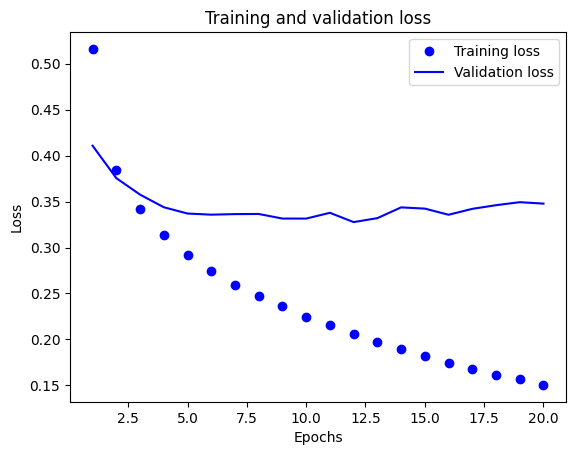

In [20]:
plot_loss_curves(history)

Вы считаете, что происходит переобучение?

Если вы считаете, что переобучение происходит на эпохе N, мы могли бы вернуться назад, переинициализировать модель и просто запустить её на N эпох — это был бы пример **ранней остановки**.

Давайте также посмотрим на кривые точности.

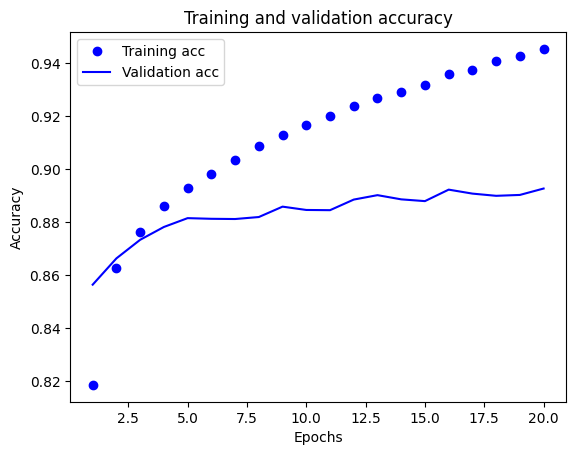

In [21]:
plot_acc_curves(history)

Что вы думаете? Не переобучаемся ли мы?

### Оценка модели

Давайте посмотрим, **насколько хорошо модель работает на тестовом наборе данных**.


In [22]:
model.evaluate(x_test, y_test)

 60/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.3964

W0000 00:00:1774624990.841040   57417 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


151/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8833 - loss: 0.3923

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8814 - loss: 0.3939


[0.3939124643802643, 0.8813999891281128]


**Это впечатляет? С чем лучше сравнить?**



### Если мы захотим добавить **второй** скрытый слой, насколько это легко?

In [23]:
# define the input layer
input = keras.Input(shape=(28,28))

# convert the 28 x 28 matrix of numbers into a long vector
h = keras.layers.Flatten()(input)

# feed the long vector to the first hidden layer
h = keras.layers.Dense(256, activation="relu", name="Hidden_1")(h)

# THIS IS THE ADDITIONAL LINE
# feed the output of the first hidden layer to the second hidden layer
h = keras.layers.Dense(256, activation="relu", name="Hidden_2")(h)

# feed the output of the second hidden layer to the output layer
output = keras.layers.Dense(10, activation="softmax", name="Output")(h)


# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

In [24]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

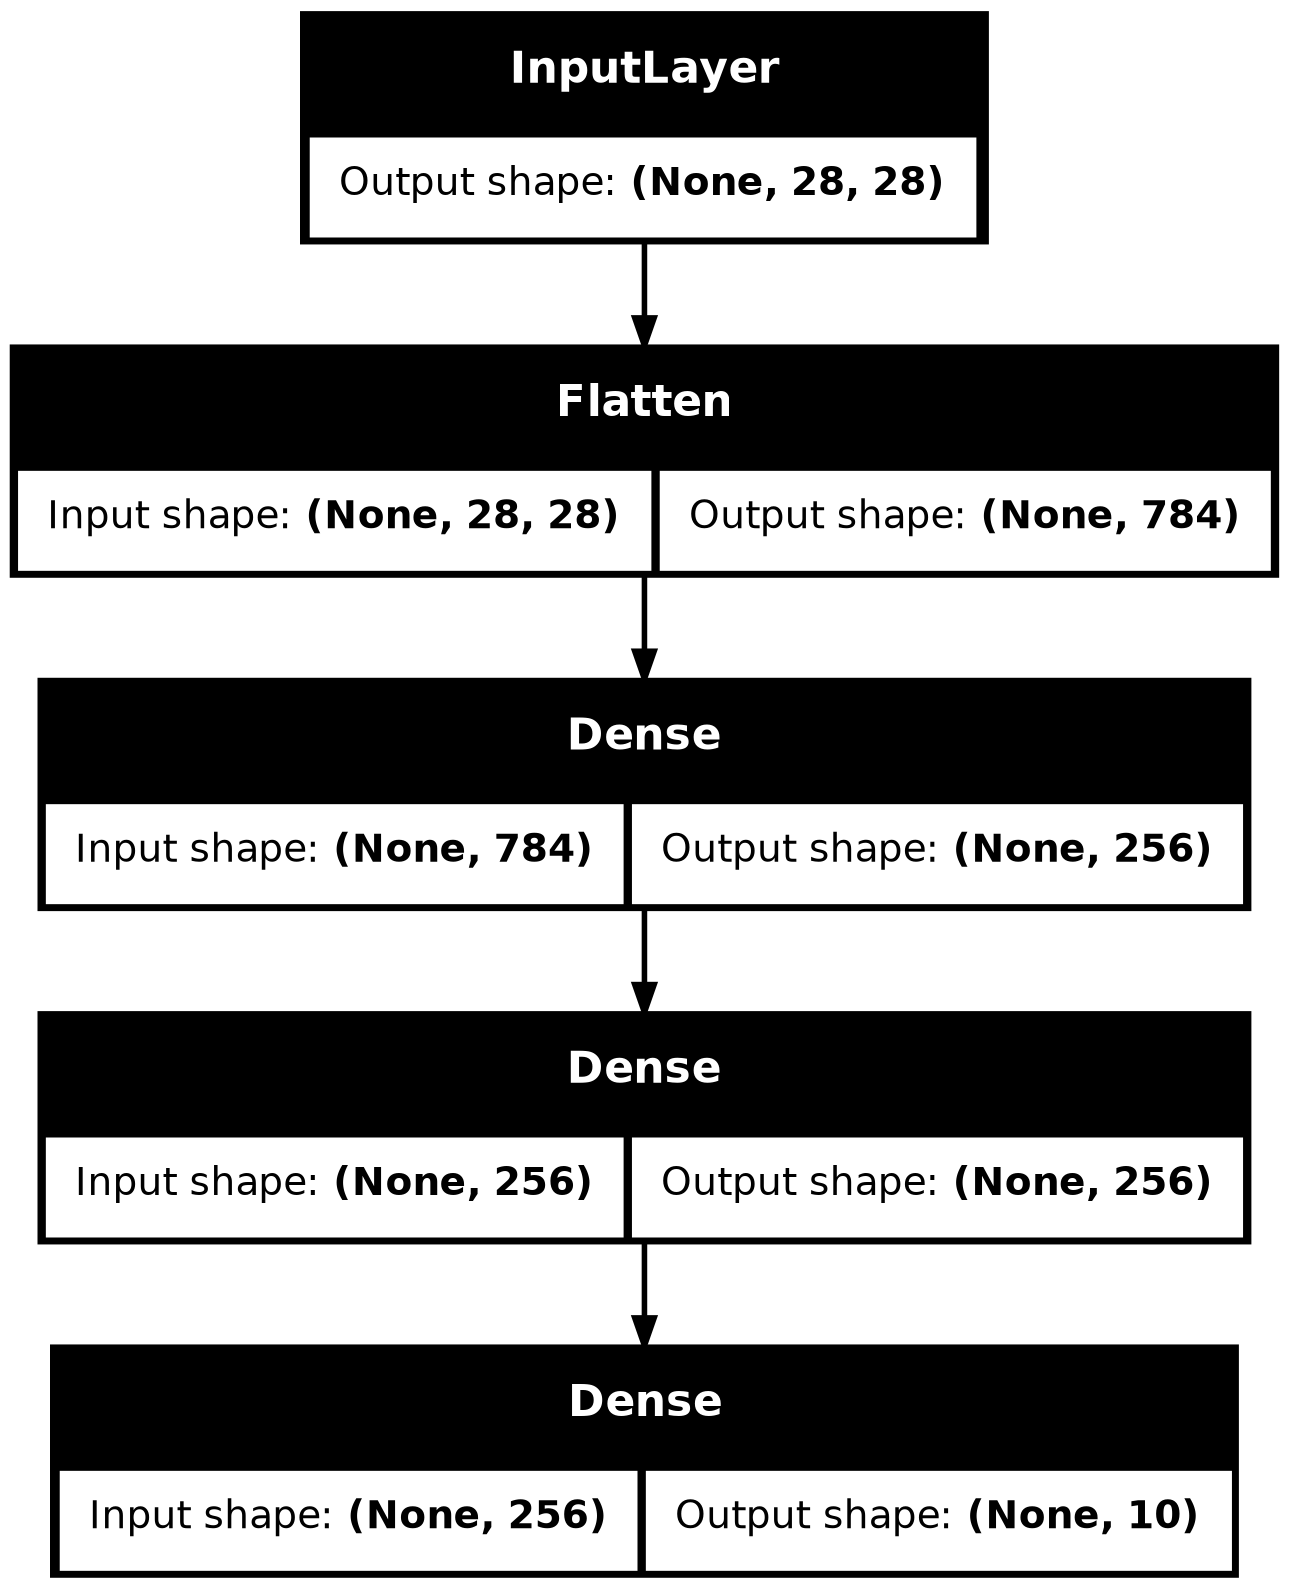

In [25]:
keras.utils.plot_model(model, show_shapes=True)

Вы можете обучить модель, показанную выше, и посмотреть, насколько хорошо она покажет себя на тестовом наборе данных.

Используйте следующие команды (как мы делали выше):


*   `model.compile`
*   `model.fit`
*   `model.evaluate`



